In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/bencmbit/datasets/refs/heads/master/insurance.csv"
medical_insurance_df = pd.read_csv(url)
medical_insurance_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
print("Missing values distribution: ")
print(medical_insurance_df.isnull().mean())
print()
# checking for missing data, no data is missing #

Missing values distribution: 
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64



In [3]:
print("Column datatypes: ")
print(medical_insurance_df.dtypes)
# checking data types, need to convert objects to numerical #

Column datatypes: 
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [4]:
medical_insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Data cleaning results**

## Exploratory Data Analysis

Text(0.5, 1.0, 'Distribution of Charges')

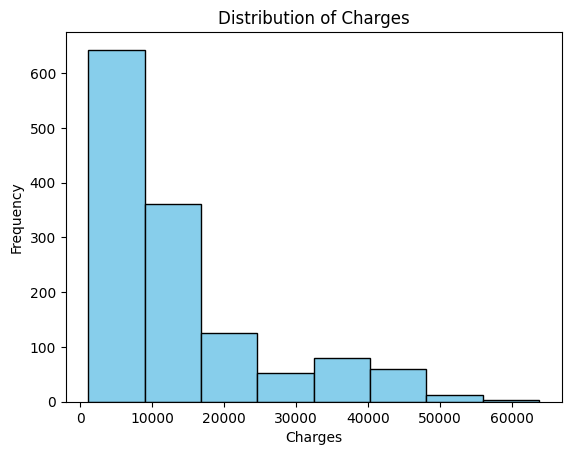

In [5]:
#Histrogram: Charges
import matplotlib.pyplot as plt
plt.hist(medical_insurance_df['charges'], bins=8, color='skyblue', edgecolor='black')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')

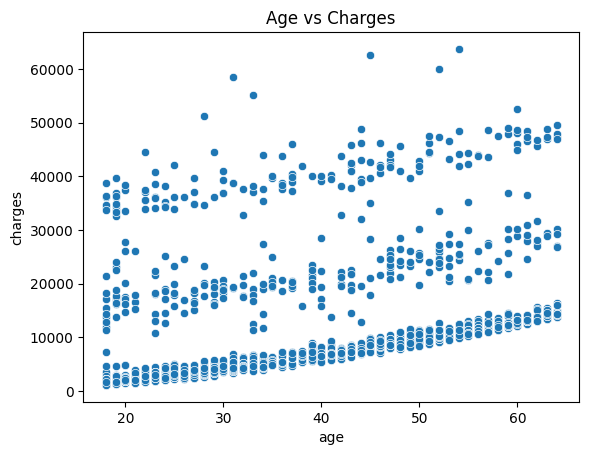

Pearsons correlation: 0.299


In [18]:
import seaborn as sns
sns.scatterplot(x='age', y='charges', data=medical_insurance_df)
plt.title('Age vs Charges')
plt.show()

from scipy import stats
Pearsons_r, p_value = stats.pearsonr(medical_insurance_df['age'], medical_insurance_df['charges'])
print("Pearsons correlation: %.3f" % Pearsons_r)


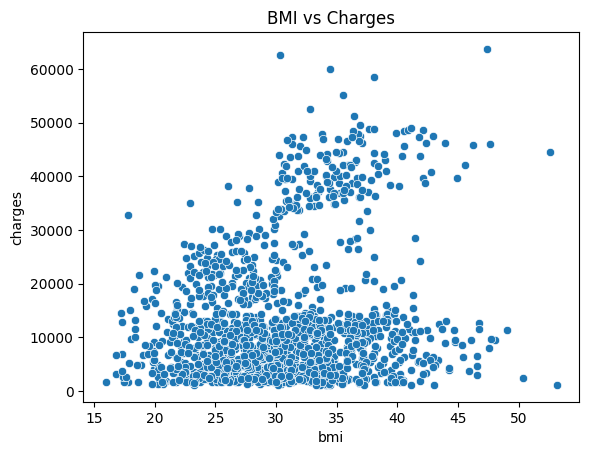

Pearsons correlation: 0.198


In [19]:
sns.scatterplot(x='bmi', y='charges', data=medical_insurance_df)
plt.title('BMI vs Charges')
plt.show()
Pearsons_r, p_value = stats.pearsonr(medical_insurance_df['bmi'], medical_insurance_df['charges'])
print("Pearsons correlation: %.3f" % Pearsons_r)

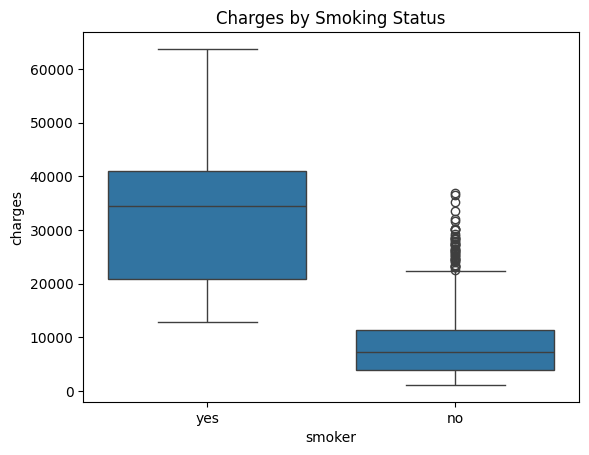

In [8]:
sns.boxplot(x='smoker', y='charges', data=medical_insurance_df)
plt.title('Charges by Smoking Status')
plt.show()

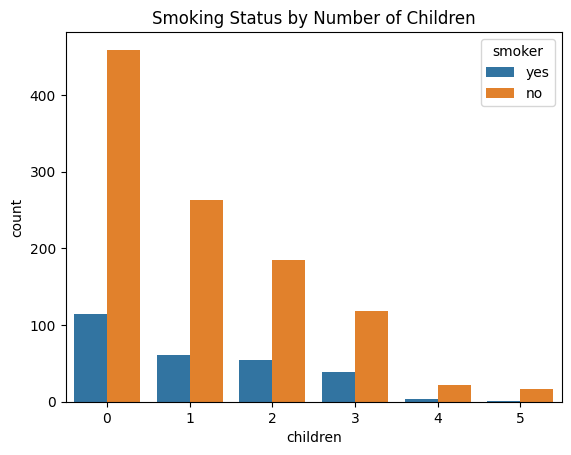

In [9]:
sns.countplot(x='children', hue='smoker', data=medical_insurance_df)
plt.title('Smoking Status by Number of Children')
plt.show()

## Based on your visualization, what modelling technique is most appropriate for your data?


**Histogram:**
The histogram is used to check how the data points are distributed across the data set. It helps us see the shape, spread and any anomalies in the which can help us determine our model choice. The histogram shows that the data is right skewed with most data points under the 20,000 mark and there is long trail reaching the max value of 60,000. Most individuals are low risk and low costs. The long tail may be individuals with chronic conditions who are high-utilizers of the health care system. This skewness might impact the regression analysis.

**Scatterplots:**
The scatterplots are used to see what the relationship between the independent variables and dependent variables looks like. The plots can also show any groups within the data like the influence of smokers vs non-smokers. Outliers can also be spotted in the data set and that can guide our analysis.

The age vs charges scatterplot shows three distinct groups in an upward trends. This shows a linear relationship, as age increases, charges rise at a constant rate. However the three distinct lines suggest that age is not the only factor, other factors are shifting individuals to higher health care costs.

The bmi vs charges scatterplot shows a fan shaped spread of the data. A high bmi doesn't necessarily mean high medical charges but can lead to higher charges. This graph again shows some interaction with other factors that lead to higher costs.

**Box plot:**
As smoking status is a categorical variable, a box plot can be used to show the distribution of charges across smoking status. The box plot can also highlight the outliers and guide further analysis. The smoking status box plot shows almost no overlap between the smoking status. The median for smokers is higher than the maximum for most non-smokers. Smoking status impacts the health care costs significantly and might be a strong predictor.

The smoking status by children plot shows the majority of individuals in every category are non-smokers. While the total number of people in the data set decreases at the number of children increases, the ratio of smokers to non-smokers seems to remain relatively stable across the groups.

Based on the exploratory data analysis, multiple linear regression is the most appropriate technique for this data set. As there are multiple independent variables, it will be interesting to see the effect of each predictor. Exploring interaction effects between predictors is beyond the scope of this analysis, so only main effects are considered. The outliers will not be removed as they do not seem to be errors, and they reflect true extreme cases. It is important to capture real-world variability especially when looking at health care data.

## Preparing data for regression analysis

In [10]:
## Turning categorical into binary variables using dummy variables, this is necessary to include categorical variables in a regression analysis
medical_insurance_transformed_df = pd.get_dummies(medical_insurance_df, columns=['sex', 'region', 'smoker'], drop_first=True)
print(medical_insurance_transformed_df.head(10))

   age     bmi  children      charges  sex_male  region_northwest  \
0   19  27.900         0  16884.92400     False             False   
1   18  33.770         1   1725.55230      True             False   
2   28  33.000         3   4449.46200      True             False   
3   33  22.705         0  21984.47061      True              True   
4   32  28.880         0   3866.85520      True              True   
5   31  25.740         0   3756.62160     False             False   
6   46  33.440         1   8240.58960     False             False   
7   37  27.740         3   7281.50560     False              True   
8   37  29.830         2   6406.41070      True             False   
9   60  25.840         0  28923.13692     False              True   

   region_southeast  region_southwest  smoker_yes  
0             False              True        True  
1              True             False       False  
2              True             False       False  
3             False             

In [22]:
## Dropping charges so the model doesn't see the y values while training, using only predictor variables to train the model
y = medical_insurance_transformed_df['charges']
X = medical_insurance_transformed_df.drop(columns=['charges'])

In [23]:
## Splitting the data set into training set and testing set
## Using 80/20 split, 80% of data is used to train the model, 20% data is left to see how it can predict the charges
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Fiting multilinear regression model to training set

In [24]:
## Finding the line of best fit through the data
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## Predicting test set results

In [27]:
## Looking at coefficients and impact of each variable on charges. Identifies the finacial weight of each factor to see which factor are large drivers of insurance charges.
print("Coefficients: ", regressor.coef_)
print("Intercept: ", regressor.intercept_)

Coefficients:  [ 2.53700500e+02  3.35962814e+02  4.36910121e+02 -1.54637279e+01
 -2.60132732e+02 -9.13278834e+02 -7.61948706e+02  2.36050173e+04]
Intercept:  -11828.073537474751


In [36]:
## Viewing the difference between the predicted and actual charges for 10 observations
results = X_test[['predicted_charges', 'actual_charges']]
results.head(10)

,predicted_charges,actual_charges
578,11169.927119,9724.53000
610,9486.709085,8547.69130
569,38181.123053,45702.02235
1034,16266.313289,12950.07120
198,6914.648007,9644.25250
981,3963.484876,4500.33925
31,1579.396913,2198.18985
1256,14385.256569,11436.73815
1219,9012.579696,7537.16390
1320,7508.460677,5425.02335


##Evaluating Model

In [29]:
## Looking at the how much the model can explain the variability in the model, how well the model fits the data. Also looking at the accuracy of the model by examining the magnitude of error
from sklearn.metrics import mean_squared_error, r2_score
score = r2_score(y_test, y_pred), mean_squared_error(y_test, y_pred)
print("R2 Score: ", score[0])
print("Mean Squared Error: ", score[1])


R2 Score:  0.7999876970680433
Mean Squared Error:  31827950.229523845


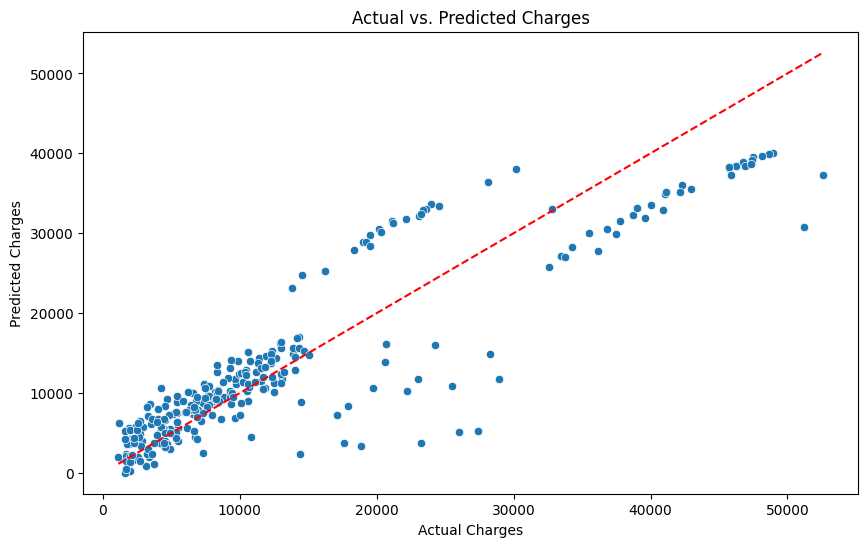

In [32]:
## A scatter plot of residuals versus predicted values to help diagnose model performance.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Charges')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

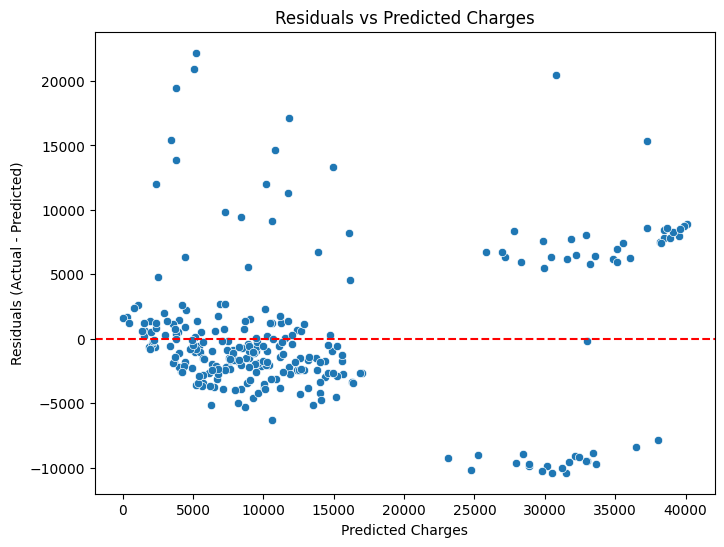

In [34]:
##A scatter plot comparing predicted values to actual values to help evaluate how well the model captures the patterns.
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Charges")
plt.show()

**R squared**
Approximately 80% of the variation in medical insurance charges can be explained by the variables in the mode. In health care data, 80% is considered substantiable and indicates that the chosen variables are strong predictors of cost.

**MSE**
While this number is larger, looking at the RMSE gives us approximately 5,641. This means that on average, the model's predictions are off by $5,641 from the actual bill.

**Actual vs Predicted charges**
This plot allows for the visualization of the model fit. The red dashed lines represents the perfect fit. As the data points generally follow the path of the red line, it supports the high R square score. The tightly packed dots at the lower end tells us that the model is quite accurate for low-cost patients but there is more complexity when predicting costs for high-risk patients.

**Residual vs Predicted charges**
A scatter plot of residuals versus predicted values helps diagnose model performance. In a perfect model, these dots would be a random cloud around the red line but instead we see a fan shape and three distinct clusters. The spread of the errors gets wider as predicted cost goes up, which also shows that the model is less accurate about predicting costs for expensive patients. The distinct clusters likely indicate that there interaction effects that the linear model is not fully capturing. This is common in health care data where risk factors multiply rather than just adding up.